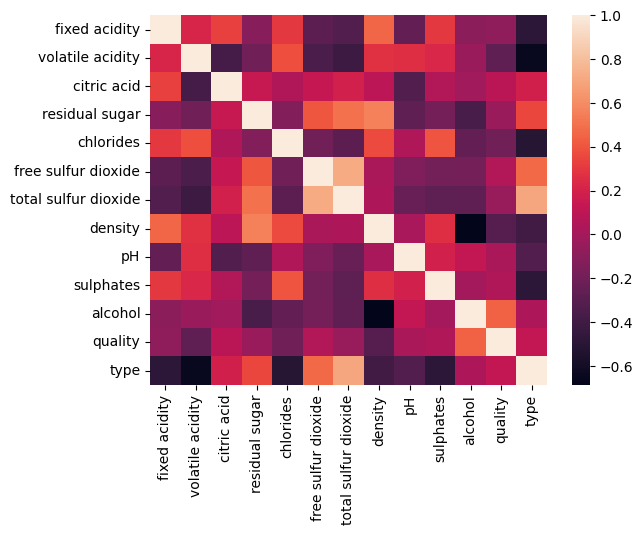

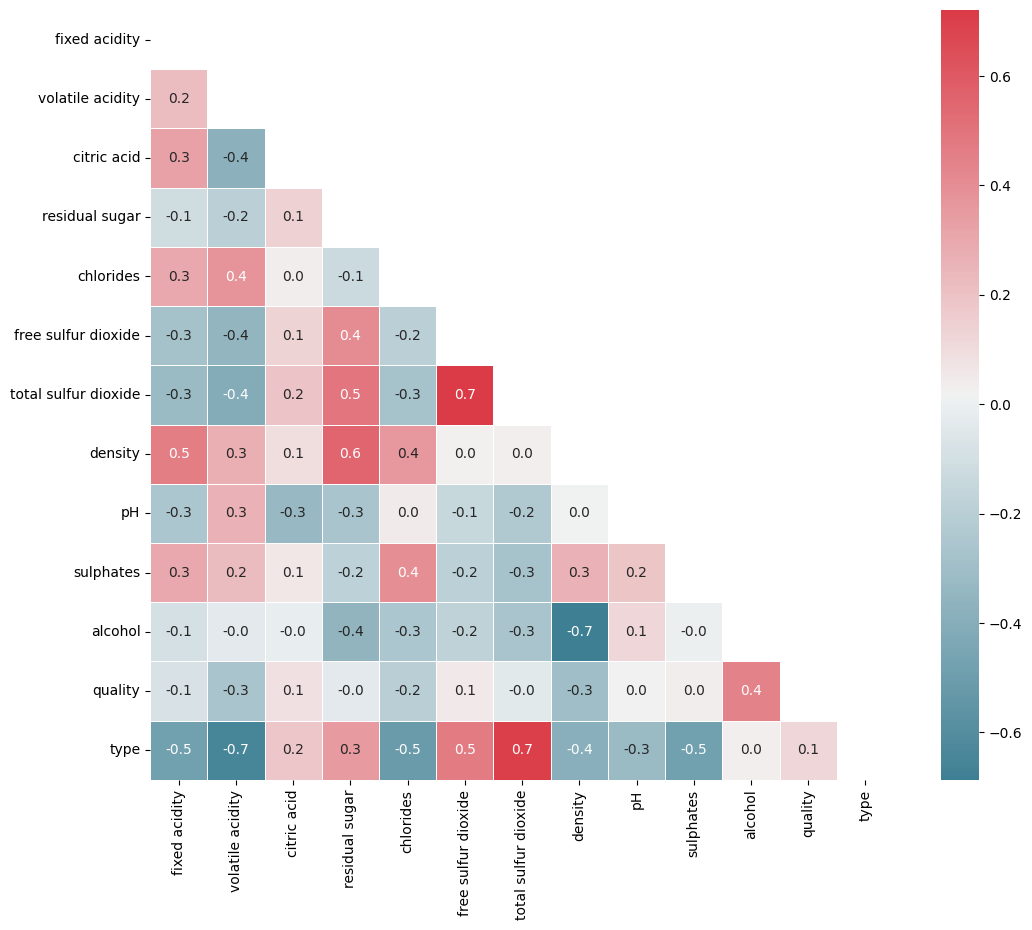

In [17]:
# This is an example of doing prediction first using machine learning models then using deep learning models.
# Such that we can compare the outcome
# So we have two data set of white wine and red wine.
# Each contains identical parametric values for each wine type.
# So we will train the models and predict the type for a given parameter set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We are using seaborn for generating heat map, which will help us to figure out the correlation between variable
import seaborn as sns

# Read data set
red = pd.read_csv('/content/sample_data/winequality-red.csv', sep=';')
white = pd.read_csv('/content/sample_data/winequality-white.csv', sep=';')

# Now label the data set
red['type'] = 0
white['type'] = 1

# Now combine the data set
wine = pd.concat([red, white])

# Now randomize the content of dataframe 'wine'
wine = wine.sample(frac=1)

# Now we will create a heat map for visualizing the correlation between variables
corr = wine.corr()
sns.heatmap(corr)
plt.show()

# We can represent the heatmap more readable way as below
f, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, linewidths=0.5, fmt='.1f', ax=ax)
plt.show()

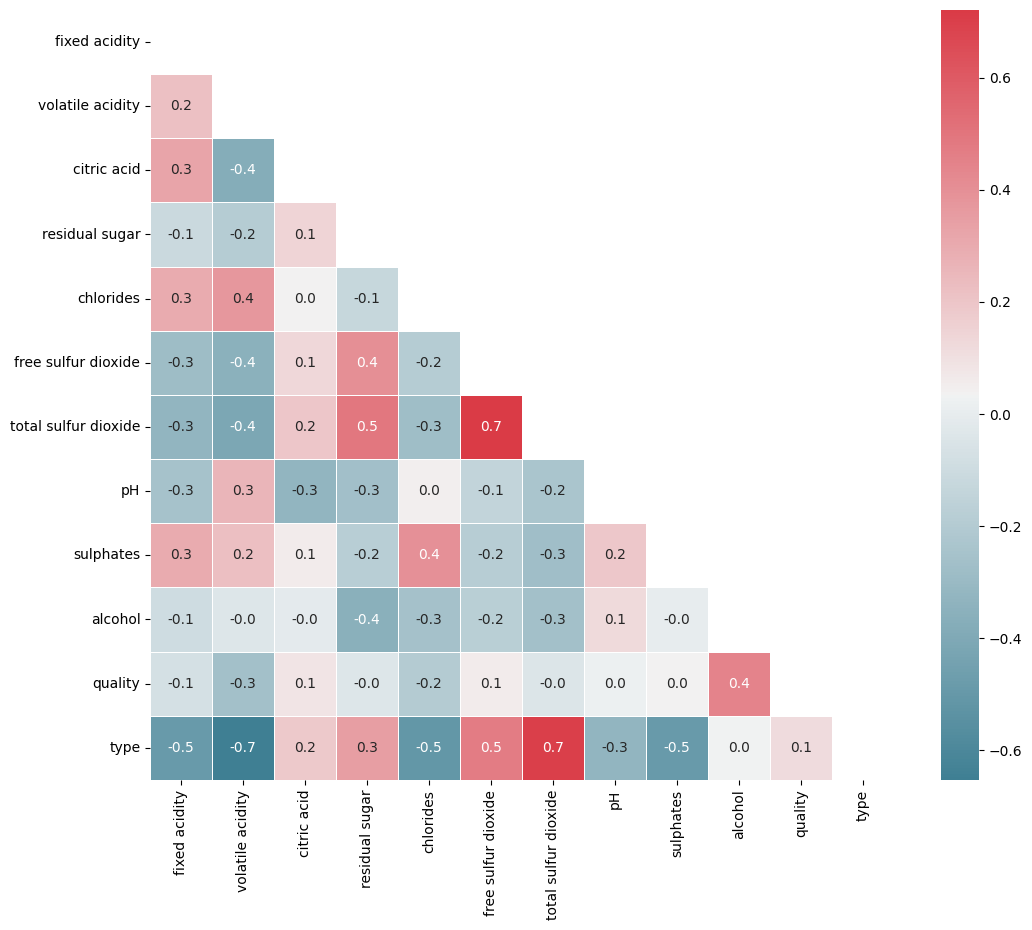

In [18]:
# From the above heat maps below fields are correlated
# 1) 'free sulfur dioxide' and 'total sulfur dioxide'
#      We cannot remove these fields as it has high correlation with dependent field 'type'
# 2) 'density' and 'residual sugar'
#      We cannot remove 'residual sugar' as it has high correlation with dependent field 'type'
#      Field 'density' can be removed as it has less correlation with dependent field 'type'
wine = wine.drop(columns=['density'], axis=1)
corr = wine.corr()

# We create the heatmap again to visualize the data
f, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, linewidths=0.5, fmt='.1f', ax=ax)
plt.show()

In [19]:
# We check for null value
wine.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
pH,0
sulphates,0
alcohol,0


In [21]:
# Now we will create training and test data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def get_ml_model():
  model = LogisticRegression()
  return model

X = wine.drop(columns=['type'], axis=1)
y = wine['type']

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X, y, test_size=0.3, random_state=2)
model = get_ml_model()
model.fit(X_train_ml, y_train_ml)

y_pred = model.predict(X_test_ml)
accuracy = accuracy_score(y_test_ml, y_pred)
print(f'Accuracy of the ML model {accuracy * 100}%')

# Now lets take a user input and determine which wine type it is
fixed_acidity = input("Enter Fixed Acidity: ")
volatile_acidity = input("Enter Volatile Acidity: ")
citric_acid = input("Enter Citric Acid: ")
residual_sugar = input("Enter Residual Sugar: ")
chlorides = input("Enter Chlorides: ")
free_sulfur_dioxide = input("Enter Free Sulfur Dioxide: ")
total_sulfur_dioxide = input("Enter Total Sulfur Dioxide: ")
pH = input("Enter pH: ")
sulphates = input("Enter Sulphates: ")
alcohol = input("Enter Alcohol: ")
quality = input("Enter quality: ")

input_data = {
    'fixed acidity': fixed_acidity,
    'volatile acidity': volatile_acidity,
    'citric acid': citric_acid,
    'residual sugar': residual_sugar,
    'chlorides': chlorides,
    'free sulfur dioxide': free_sulfur_dioxide,
    'total sulfur dioxide': total_sulfur_dioxide,
    'pH': pH,
    'sulphates': sulphates,
    'alcohol': alcohol,
    'quality': quality
}

input_df = pd.DataFrame([input_data])

input_pred = model.predict(input_df)

if int(input_pred[0]) == 0:
  print("\nIts Red Wine")
else:
  print("\nIts White")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of the ML model 98.2051282051282%
Enter Fixed Acidity: 7.5
Enter Volatile Acidity: 0.50
Enter Citric Acid: 0.36
Enter Residual Sugar: 6.1
Enter Chlorides: 0.071
Enter Free Sulfur Dioxide: 17.0
Enter Total Sulfur Dioxide: 102.0
Enter pH: 3.35
Enter Sulphates: 0.80
Enter Alcohol: 10.5
Enter quality: 5

Its Red Wine


In [22]:
# Now we will use deep learning model to do the prediction
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import classification_report

def get_deep_learning_model():
  deep_model = Sequential()
  # In our case we have 11 independent variables and we can have one probability value for the output.
  # That means output layer needs to be on neuron

  # Here we are defining 12 neurons in the input layer. This can be any number.
  # Activation function we using as RelU
  # Input shape is 11, because we have 11 independent variables
  deep_model.add(Dense(20, activation='relu', input_shape=(11,))) # This is the input layer
  deep_model.add(Dense(15, activation='relu')) # This is the hidden layer
  deep_model.add(Dense(10, activation='relu')) # This is the hidden layer
  deep_model.add(Dense(5, activation='relu')) # This is the hidden layer
  deep_model.add(Dense(1, activation='sigmoid')) # This is the output layer. We are using sigmoid in output layer because we have classification problem

  deep_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

  return deep_model;

X = wine.drop(columns=['type'], axis=1)
y = wine['type']

# Here we need to convert dependent variable 'y' to a single dimensional numpy array for deep learning model training
y = np.ravel(y)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X, y, test_size=0.3, random_state=2)

deep_model = get_deep_learning_model()
deep_model.fit(X_train_dl, y_train_dl, epochs=10, batch_size=1, verbose=1)

# Now we will do the prediction
y_pred = deep_model.predict(X_test_dl)
y_pred = np.ravel(y_pred) # This we are converting it single dimension numpy array
y_pred = np.where(y_pred > 0.5, 1 , 0) # Convert prediction array to 0 and 1
print(classification_report(y_test_dl, y_pred))  # Read note on classificatio  report

loss, accuracy = deep_model.evaluate(X_test_dl, y_test_dl)
print(f"Accuracy: {accuracy * 100}%")

# Now lets take a user input and determine which wine type it is
fixed_acidity = input("Enter Fixed Acidity: ")
volatile_acidity = input("Enter Volatile Acidity: ")
citric_acid = input("Enter Citric Acid: ")
residual_sugar = input("Enter Residual Sugar: ")
chlorides = input("Enter Chlorides: ")
free_sulfur_dioxide = input("Enter Free Sulfur Dioxide: ")
total_sulfur_dioxide = input("Enter Total Sulfur Dioxide: ")
pH = input("Enter pH: ")
sulphates = input("Enter Sulphates: ")
alcohol = input("Enter Alcohol: ")
quality = input("Enter quality: ")

input_data = {
    'fixed acidity': fixed_acidity,
    'volatile acidity': volatile_acidity,
    'citric acid': citric_acid,
    'residual sugar': residual_sugar,
    'chlorides': chlorides,
    'free sulfur dioxide': free_sulfur_dioxide,
    'total sulfur dioxide': total_sulfur_dioxide,
    'pH': pH,
    'sulphates': sulphates,
    'alcohol': alcohol,
    'quality': quality
}

input_df = pd.DataFrame([input_data])

# Convert the entire DataFrame to float values ---
input_df = input_df.astype(float)

input_pred = deep_model.predict(input_df)
print(input_pred)
if float(input_pred[0][0]) > 0.5:
  print("Its White Wine")
else:
  print("Its Red")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4547/4547 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9199 - loss: 0.2262
Epoch 2/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9345 - loss: 0.1881
Epoch 3/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9472 - loss: 0.1536
Epoch 4/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9589 - loss: 0.1277
Epoch 5/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9631 - loss: 0.1147
Epoch 6/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9637 - loss: 0.1088
Epoch 7/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9681 - loss: 0.0993
Epoch 8/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9672 - loss: 0.0975
Epoch 9/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9718 - loss: 0.0950
Epoch 10/10
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9729 - loss: 0.0852
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.96      0.96 

In [23]:
# Now we supply a data set of different wine bottles details and let ML and DL model predict the type of wine
input_data = pd.read_csv('/content/sample_data/input_data_for_wine_test.csv')
shuffled_df = input_data.sample(frac=1)
shuffled_df = shuffled_df.astype(float)
wine_parameters = shuffled_df.drop(columns=['density','type'], axis=1)
wine_type_known = shuffled_df['type']

wine_parameters = wine_parameters.astype(float)
wine_type_known = wine_type_known.astype(float)

# First we do prediction using ML model
y_pred_using_ml = model.predict(wine_parameters)

number_of_wine_bottles = len(wine_parameters)
matched_prediction = 0
unmatched_df_X = pd.DataFrame()
unmatched_df_y = pd.Series()

for index in range(20):
  if float(y_pred_using_ml[index]) == float(wine_type_known.iloc[index]):
    matched_prediction = matched_prediction + 1
    if float(y_pred_using_ml[index]) == 1.0:
      print(f'Bottle {index + 1} is White wine')
    else:
      print(f'Bottle {index + 1} is Red wine')
  else:
    print(f'Prediction not matched for bottle {index + 1}')
    unmatched_df_X = pd.concat([unmatched_df_X, wine_parameters.iloc[index].to_frame().T], ignore_index=True)
    unmatched_df_y = pd.concat([unmatched_df_y, pd.Series(wine_type_known.iloc[index])], ignore_index=True)

unmatched_df_X = unmatched_df_X.astype(float)
unmatched_df_y = unmatched_df_y.astype(float)
unmatched_df_y.name = 'type'
print(f'Prediction accuracy with ML model: {(matched_prediction / number_of_wine_bottles) * 100}%')

print("\nUnmatched DataSet")
print(unmatched_df_X.to_string())
print('-' * 200)
print(unmatched_df_y.to_string(),"\n")

# Its possible that there will be incorrect label in pre trained data. So we need to correct that using known data
for index, row in unmatched_df_X.iterrows():
  row_mask =  (X_train_ml['fixed acidity'] == row['fixed acidity']) & (X_train_ml['volatile acidity'] == row['volatile acidity']) & (X_train_ml['citric acid'] == row['citric acid']) & (X_train_ml['residual sugar'] == row['residual sugar']) & (X_train_ml['chlorides'] == row['chlorides']) & (X_train_ml['free sulfur dioxide'] == row['free sulfur dioxide']) & (X_train_ml['total sulfur dioxide'] == row['total sulfur dioxide']) & (X_train_ml['pH'] == row['pH']) & (X_train_ml['sulphates'] == row['sulphates']) & (X_train_ml['alcohol'] == row['alcohol']) & (X_train_ml['quality'] == row['quality'])
  positions = np.where(row_mask)[0]
  for position in positions:
    if unmatched_df_y.iloc[index] != y_train_ml.iloc[position]:
      y_train_ml.iloc[position] = unmatched_df_y.iloc[index]


Prediction not matched for bottle 1
Bottle 2 is White wine
Bottle 3 is White wine
Bottle 4 is Red wine
Bottle 5 is White wine
Bottle 6 is Red wine
Bottle 7 is Red wine
Bottle 8 is Red wine
Bottle 9 is Red wine
Bottle 10 is White wine
Bottle 11 is Red wine
Bottle 12 is White wine
Bottle 13 is White wine
Bottle 14 is White wine
Bottle 15 is White wine
Bottle 16 is Red wine
Bottle 17 is White wine
Bottle 18 is Red wine
Bottle 19 is Red wine
Bottle 20 is White wine
Prediction accuracy with ML model: 95.0%

Unmatched DataSet
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide    pH  sulphates  alcohol  quality
0            6.7              0.28         0.28             2.4      0.012                 36.0                 100.0  3.26       0.39     11.7      7.0
------------------------------------------------------------------------------------------------------------------------------------------------------------------------

/tmp/ipykernel_544/2153477863.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  unmatched_df_y = pd.concat([unmatched_df_y, pd.Series(wine_type_known.iloc[index])], ignore_index=True)


In [24]:
# Now lets make copy of X_train_ml and y_train_ml and then add new unpredicted data set to that with known value
# And then train the model and see whether prediction is coming correct or not
X_re_train_ml = pd.concat([X_train_ml, unmatched_df_X])
y_re_train_ml = pd.concat([y_train_ml, unmatched_df_y])

print(X_train_ml.shape, '--', y_train_ml.shape)
print(X_re_train_ml.shape, '--', y_re_train_ml.shape)
ml_model = get_ml_model()
ml_model.fit(X_re_train_ml, y_re_train_ml)

# Retry prediction using ML model
y_pred_using_ml = ml_model.predict(wine_parameters)
number_of_wine_bottles = len(wine_parameters)
matched_prediction = 0
unmatched_df_X = pd.DataFrame()
unmatched_df_y = pd.Series()

for index in range(20):
  if float(y_pred_using_ml[index]) == float(wine_type_known.iloc[index]):
    matched_prediction = matched_prediction + 1
    if float(y_pred_using_ml[index]) == 1.0:
      print(f'Bottle {index + 1} is White wine')
    else:
      print(f'Bottle {index + 1} is Red wine')
  else:
    print(f'Prediction not matched for bottle {index + 1}. PRED[{float(y_pred_using_ml[index])}, {float(wine_type_known.iloc[index])}]')
    unmatched_df_X = pd.concat([unmatched_df_X, wine_parameters.iloc[index].to_frame().T], ignore_index=True)
    unmatched_df_y = pd.concat([unmatched_df_y, pd.Series(wine_type_known.iloc[index])], ignore_index=True)

unmatched_df_y.name = 'type'
print(f'Prediction accuracy with ML model: {(matched_prediction / number_of_wine_bottles) * 100}%')

print("\nUnmatched DataSet")
print(unmatched_df_X.to_string())
print('-' * 200)
print(unmatched_df_y.to_string(),"\n")

(4547, 11) -- (4547,)
(4548, 11) -- (4548,)
Prediction not matched for bottle 1. PRED[1.0, 0.0]
Bottle 2 is White wine
Bottle 3 is White wine
Bottle 4 is Red wine
Bottle 5 is White wine
Bottle 6 is Red wine
Bottle 7 is Red wine
Bottle 8 is Red wine
Bottle 9 is Red wine
Bottle 10 is White wine
Bottle 11 is Red wine
Bottle 12 is White wine
Bottle 13 is White wine
Bottle 14 is White wine
Bottle 15 is White wine
Bottle 16 is Red wine
Bottle 17 is White wine
Bottle 18 is Red wine
Bottle 19 is Red wine
Bottle 20 is White wine
Prediction accuracy with ML model: 95.0%

Unmatched DataSet
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide    pH  sulphates  alcohol  quality
0            6.7              0.28         0.28             2.4      0.012                 36.0                 100.0  3.26       0.39     11.7      7.0
------------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_544/274427412.py:28: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  unmatched_df_y = pd.concat([unmatched_df_y, pd.Series(wine_type_known.iloc[index])], ignore_index=True)


In [26]:
# If two samples from different classes have near-identical numerical features, a linear model will always struggle.
# Non-linear algorithms can easily capture complex boundaries and isolated clusters:

from sklearn.ensemble import RandomForestClassifier

# Random Forest can easily handle localized/non-linear boundaries
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_re_train_ml, y_re_train_ml)

y_pred_using_ml = rf_model.predict(wine_parameters)
number_of_wine_bottles = len(wine_parameters)
matched_prediction = 0
unmatched_df_X = pd.DataFrame()
unmatched_df_y = pd.Series()

for index in range(20):
  if float(y_pred_using_ml[index]) == float(wine_type_known.iloc[index]):
    matched_prediction = matched_prediction + 1
    if float(y_pred_using_ml[index]) == 1.0:
      print(f'Bottle {index + 1} is White wine')
    else:
      print(f'Bottle {index + 1} is Red wine')
  else:
    print(f'Prediction not matched for bottle {index + 1}. PRED[{float(y_pred_using_ml[index])}, {float(wine_type_known.iloc[index])}]')
    unmatched_df_X = pd.concat([unmatched_df_X, wine_parameters.iloc[index].to_frame().T], ignore_index=True)
    unmatched_df_y = pd.concat([unmatched_df_y, pd.Series(wine_type_known.iloc[index])], ignore_index=True)

unmatched_df_y.name = 'type'
print(f'Prediction accuracy with ML model: {(matched_prediction / number_of_wine_bottles) * 100}%')


Bottle 1 is Red wine
Bottle 2 is White wine
Bottle 3 is White wine
Bottle 4 is Red wine
Bottle 5 is White wine
Bottle 6 is Red wine
Bottle 7 is Red wine
Bottle 8 is Red wine
Bottle 9 is Red wine
Bottle 10 is White wine
Bottle 11 is Red wine
Bottle 12 is White wine
Bottle 13 is White wine
Bottle 14 is White wine
Bottle 15 is White wine
Bottle 16 is Red wine
Bottle 17 is White wine
Bottle 18 is Red wine
Bottle 19 is Red wine
Bottle 20 is White wine
Prediction accuracy with ML model: 100.0%


In [28]:
# Now we use deep learning model for prediction
y_pred_using_dl = deep_model.predict(wine_parameters)
y_pred_using_dl = np.ravel(y_pred_using_dl) # This we are converting it single dimension numpy array
y_pred_using_dl = np.where(y_pred_using_dl > 0.5, 1 , 0) # Convert prediction array to 0 and 1

number_of_wine_bottles = len(wine_parameters)
matched_prediction = 0
unmatched_df = pd.DataFrame()

for index in range(20):
  if float(y_pred_using_dl[index]) == float(wine_type_known.iloc[index]):
    matched_prediction = matched_prediction + 1
    if float(y_pred_using_dl[index]) == 1.0:
      print(f'Bottle {index + 1} is White wine')
    else:
      print(f'Bottle {index + 1} is Red wine')
  else:
    print(f'Prediction not matched for bottle {index + 1}, PRED[{float(y_pred_using_dl[0])}, {float(wine_type_known.iloc[index])}]')
    unmatched_df = pd.concat([unmatched_df, wine_parameters.iloc[index].to_frame().T], ignore_index=True)

print(f'Prediction accuracy with ML model: {(matched_prediction / number_of_wine_bottles) * 100}%')
print("\nUnmatched DataSet")
unmatched_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction not matched for bottle 1, PRED[1.0, 0.0]
Bottle 2 is White wine
Bottle 3 is White wine
Bottle 4 is Red wine
Bottle 5 is White wine
Bottle 6 is Red wine
Bottle 7 is Red wine
Bottle 8 is Red wine
Bottle 9 is Red wine
Bottle 10 is White wine
Bottle 11 is Red wine
Bottle 12 is White wine
Bottle 13 is White wine
Bottle 14 is White wine
Bottle 15 is White wine
Bottle 16 is Red wine
Bottle 17 is White wine
Bottle 18 is Red wine
Bottle 19 is Red wine
Bottle 20 is White wine
Prediction accuracy with ML model: 95.0%

Unmatched DataSet


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,6.7,0.28,0.28,2.4,0.012,36.0,100.0,3.26,0.39,11.7,7.0


In [ ]:
# From above testing we can say best suited algorithm for model is RandomForestClassifier